# Dithering algorithm comparison

The 6-colour ACeP palette can only show Black, White, Yellow, Red, Blue, and
Green, so the dithering algorithm choice has a big effect on perceived image
quality. This notebook applies a curated set of error-diffusion and
ordered-dithering algorithms to a few photos and shows them side-by-side, with
timing.

It uses the small CC-licensed set bundled under `photos/` (a mix of
saturated colour, fine detail, and smooth gradients to stress the palette in
different ways).

Production uses Atkinson with perceptual weighting. `atkinson_weighted` is the
closest pure-Python match; the version that actually ships is numba-JIT'd and
equivalent to `atkinson_fast`.

Algorithm taxonomy:

- **Error diffusion** (`floyd_steinberg`, `atkinson`, `jarvis`, `stucki`,
  `sierra`, `sierra_lite`, `burkes`): quantise pixels left-to-right, push the
  rounding error onto unprocessed neighbours.
- **Ordered** (`bayer4`, `bayer8`, `bayer4_strong`): add a deterministic
  threshold pattern before quantising. No error spreading; pattern is
  independent of content.
- **PIL built-ins** (`pil_fs`, `pil_none`): reference.

In [6]:
import sys

sys.path.insert(0, ".")
from _helpers import PHOTOS_DIR, bootstrap, center_crop, local_pool, open_image, silenced

bootstrap()

import time

import numpy as np
from _dither import DITHER_ALGORITHMS, PALETTE_NAMES, PALETTE_RGB, apply_dithering
from PIL import Image
from waveshare_epd.epd7in3e import EPD_HEIGHT, EPD_WIDTH

# Pure-Python algorithms run at ~30s per 800x480 image; keep a curated subset by default.
# Toggle SHOW_ALL = True to run everything (will take several minutes).
DEFAULT_ALGOS = [
    "atkinson_fast",
    "atkinson",
    "atkinson_weighted",
    "floyd_steinberg",
    "floyd_steinberg_weighted",
    "jarvis",
    "sierra_lite",
    "burkes",
    "bayer4",
    "bayer8",
    "pil_fs",
    "none",
]
SHOW_ALL = False
ALGOS = list(DITHER_ALGORITHMS.keys()) if SHOW_ALL else DEFAULT_ALGOS

N_PHOTOS = 2  # one image cycle per photo
SEED = 11

hiker_in_mountains.jpg
leopard_on_road.jpg


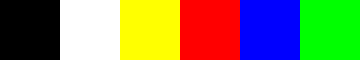

In [7]:
pool_assets = local_pool()[:20]

with silenced():
    sources = []
    for asset in pool_assets[:N_PHOTOS]:
        img = open_image(asset)
        sources.append((asset, center_crop(img, EPD_WIDTH, EPD_HEIGHT)))

for asset, _ in sources:
    print(asset.get("originalFileName") or asset["id"])

# Render the 6-colour palette as a tiny banner so the colour budget is visible.
swatch_h = 60
swatch_w = 60
palette_strip = np.zeros((swatch_h, swatch_w * len(PALETTE_RGB), 3), dtype=np.uint8)
for i, rgb in enumerate(PALETTE_RGB):
    palette_strip[:, i * swatch_w : (i + 1) * swatch_w] = rgb
Image.fromarray(palette_strip)

In [8]:
results = []  # list of dict per (photo, algo)
for asset, source in sources:
    name = asset.get("originalFileName") or asset["id"]
    print(f"[{name}]")
    photo_results = []
    for algo in ALGOS:
        info = DITHER_ALGORITHMS[algo]
        t0 = time.perf_counter()
        out = apply_dithering(source, algo)
        dt = time.perf_counter() - t0
        photo_results.append({"algo": algo, "name": info["name"], "image": out, "duration": dt})
        print(f"  {info['name']:32s}  {dt:6.2f}s")
    results.append({"asset": asset, "source": source, "algos": photo_results})

[hiker_in_mountains.jpg]
  Atkinson (Numba Fast)               0.01s
  Atkinson                            3.90s
  Atkinson (Weighted)                 4.24s
  Floyd-Steinberg                     3.79s
  Floyd-Steinberg (Weighted)          4.16s
  Jarvis-Judice-Ninke                 8.40s
  Sierra Lite                         3.19s
  Burkes                              5.47s
  Ordered (Bayer 4x4)                 2.21s
  Ordered (Bayer 8x8)                 2.18s
  Floyd-Steinberg (PIL)               0.01s
  No Dithering (PIL)                  0.00s
[leopard_on_road.jpg]
  Atkinson (Numba Fast)               0.01s
  Atkinson                            3.79s
  Atkinson (Weighted)                 4.15s
  Floyd-Steinberg                     3.77s
  Floyd-Steinberg (Weighted)          4.20s
  Jarvis-Judice-Ninke                 8.45s
  Sierra Lite                         3.25s
  Burkes                              5.46s
  Ordered (Bayer 4x4)                 2.16s
  Ordered (Bayer 8x8)        

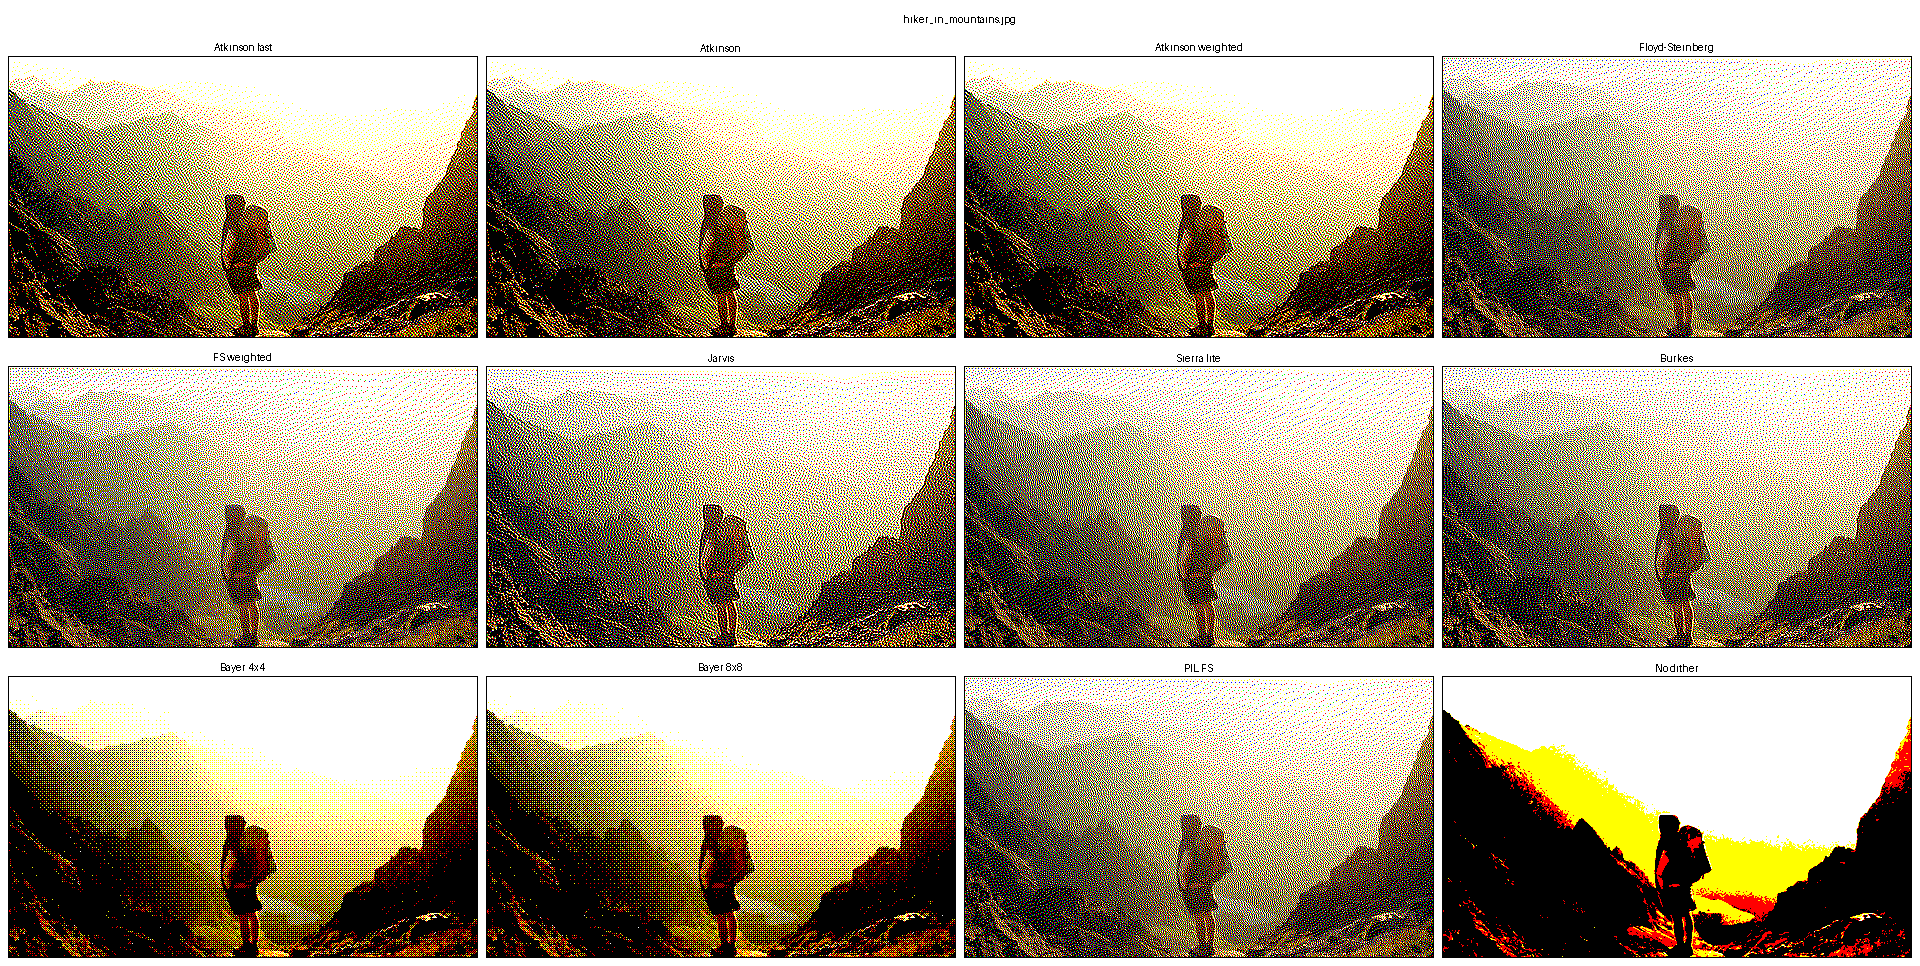

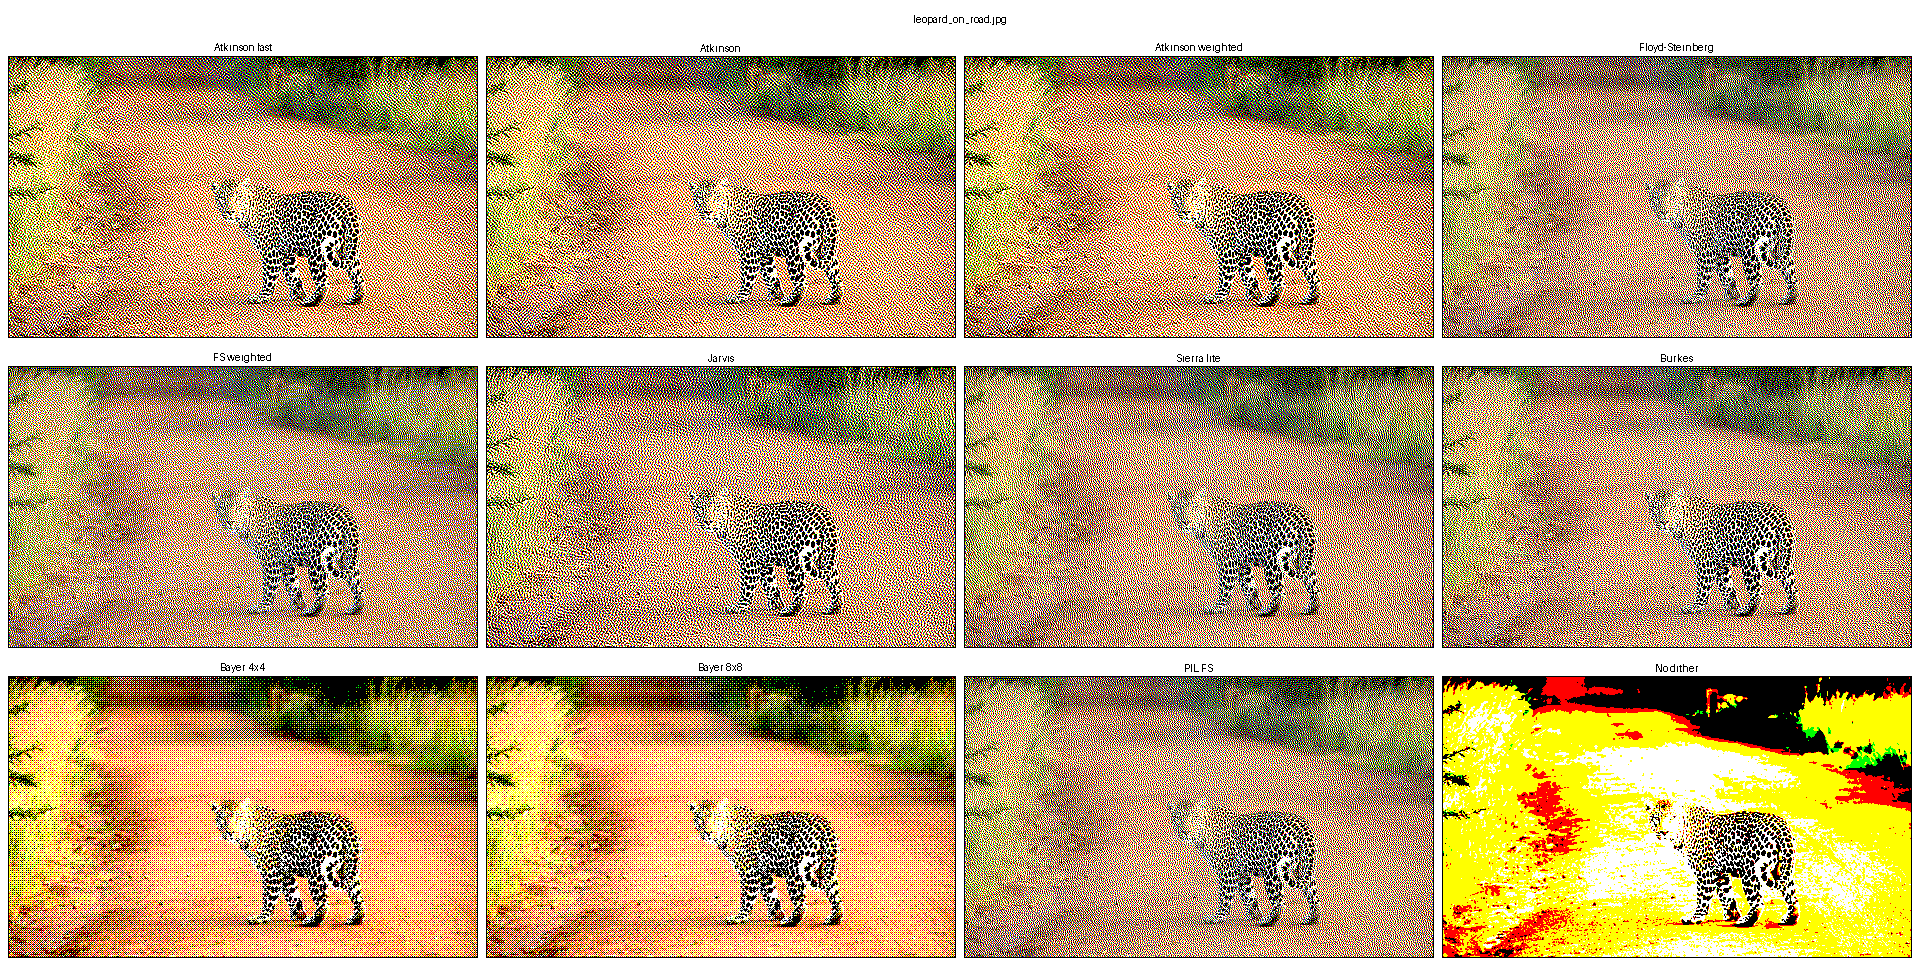

In [9]:
# One palette-preserving contact sheet per photo. The cell above dithers at the
# full EPD resolution to time each algorithm; for the contact sheet we downscale
# the source first and then dither, so the dither pattern is sized for the tile
# rather than aliased away by a NEAREST resize of a high-frequency dither.
from math import ceil
from pathlib import Path

from IPython.display import display
from PIL import ImageDraw, ImageFont

SHORT_NAMES = {
    "atkinson_fast": "Atkinson fast",
    "atkinson": "Atkinson",
    "atkinson_weighted": "Atkinson weighted",
    "floyd_steinberg": "Floyd-Steinberg",
    "floyd_steinberg_weighted": "FS weighted",
    "jarvis": "Jarvis",
    "sierra_lite": "Sierra lite",
    "burkes": "Burkes",
    "bayer4": "Bayer 4x4",
    "bayer8": "Bayer 8x8",
    "pil_fs": "PIL FS",
    "none": "No dither",
}
SHOWCASE_WIDTH = 1920
COLS = 4
GUTTER = 8
LABEL_H = 20
TITLE_H = 20
TILE_W = (SHOWCASE_WIDTH - GUTTER * (COLS + 1)) // COLS
TILE_H = EPD_HEIGHT * TILE_W // EPD_WIDTH
FONT = ImageFont.load_default()
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)


def _display_palette_image():
    pal = Image.new("P", (1, 1))
    flat = []
    for rgb in PALETTE_RGB:
        flat.extend(rgb)
    flat.extend([0] * (768 - len(flat)))
    pal.putpalette(flat)
    return pal


DISPLAY_PALETTE = _display_palette_image()


def _centered_text(draw, box, text):
    bbox = draw.textbbox((0, 0), text, font=FONT)
    tw, th = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x0, y0, x1, y1 = box
    draw.text((x0 + (x1 - x0 - tw) // 2, y0 + (y1 - y0 - th) // 2), text, fill=BLACK, font=FONT)


def make_dither_showcase(entry):
    rows = ceil(len(entry["algos"]) / COLS)
    height = GUTTER + TITLE_H + GUTTER + rows * (LABEL_H + TILE_H + GUTTER)
    sheet = Image.new("RGB", (SHOWCASE_WIDTH, height), WHITE)
    draw = ImageDraw.Draw(sheet)
    name = entry["asset"].get("originalFileName") or entry["asset"]["id"]
    _centered_text(draw, (0, GUTTER, SHOWCASE_WIDTH, GUTTER + TITLE_H), name)

    tile_source = entry["source"].resize((TILE_W, TILE_H), Image.Resampling.LANCZOS)

    top = GUTTER + TITLE_H + GUTTER
    for i, result in enumerate(entry["algos"]):
        col = i % COLS
        row = i // COLS
        x = GUTTER + col * (TILE_W + GUTTER)
        y = top + row * (LABEL_H + TILE_H + GUTTER)
        _centered_text(draw, (x, y, x + TILE_W, y + LABEL_H), SHORT_NAMES[result["algo"]])
        tile = apply_dithering(tile_source, result["algo"])
        sheet.paste(tile, (x, y + LABEL_H))
        draw.rectangle((x, y + LABEL_H, x + TILE_W - 1, y + LABEL_H + TILE_H - 1), outline=BLACK)

    return sheet.quantize(palette=DISPLAY_PALETTE, dither=Image.Dither.NONE).convert("RGB")


for entry in results:
    sheet = make_dither_showcase(entry)
    name = entry["asset"].get("originalFileName") or entry["asset"]["id"]
    out_path = PHOTOS_DIR / f"dither_compare_{Path(name).stem}.png"
    sheet.save(out_path, optimize=True)
    display(sheet)